In [1]:
%matplotlib inline
import warnings
from fractions import Fraction
from typing import List
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from monodromy.coordinates import (
    monodromy_to_positive_canonical_coordinate,
    positive_canonical_to_monodromy_coordinate,
)
from monodromy.coverage import CircuitPolytope
from monodromy.haar import (
    haar_volume,
)
from monodromy.polytopes import ConvexPolytope
from monodromy.utilities import fractionify
from qiskit.circuit.library import CXGate, SwapGate, UnitaryGate, iSwapGate
from tqdm.notebook import tqdm
from weylchamber import WeylChamber
from hetero_isas.zz_parallel_drive.ansatz import (
    BasicCircuitAnsatz,
    CircuitAnsatz,
)
from hetero_isas.numerical_decomp import (
    ClosestInvariantSearch,
    InvariantConvergenceWarning,
)

In [88]:
# TODO adaptive convex-hull? faster routine if have existing hull + new points?
# FIXME mix-matching coordinate conventions!!!
# when we add to ansatz.point_cloud we aren't enforcing correctly

# I think the best thing would be to always work with monodromy. only convert when plotting...

In [89]:
def _ansatz_to_circuit_polytope(ansatz: CircuitAnsatz, cost=0) -> CircuitPolytope:
    ansatz.generate_points(method="monodromy", num_samples=10_000)

    # TODO: advanced boundary searching
    flat_list = [coord for inner_cord in ansatz.point_cloud for coord in inner_cord]
    pc: List[List[Fraction]] = fractionify(flat_list)
    convex_hull = ConvexPolytope.convex_hull(pc)

    # FIXME, these parameters are grabbing the matrix elements of the gate
    # we need a better way to distinguish between operators
    return CircuitPolytope(
        operations=[str(ansatz)],
        cost=cost,
        convex_subpolytopes=[convex_hull],
    )

In [90]:
ansatz = BasicCircuitAnsatz(iSwapGate().power(1 / 2), 3, u_sequence=[(3, 3), (3, 3)])
# ansatz = BasicCircuitAnsatz(iSwapGate().power(1 / 2), 2, u_sequence=[(2, 3)])

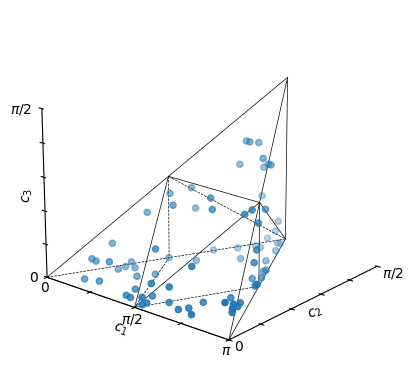

In [91]:
ax = plt.subplot(111, projection="3d")
w = WeylChamber()
w.labels = {}
w.render(ax)

cp = _ansatz_to_circuit_polytope(ansatz)
for idx, subpolytope in enumerate(cp.convex_subpolytopes):
    weyl_vertices = [
        monodromy_to_positive_canonical_coordinate(*monodromy_vertex[:3])
        for monodromy_vertex in subpolytope.vertices
    ]
    weyl_vertices = np.array(weyl_vertices) / (np.pi / 2)
    w.ax.scatter3D(*zip(*weyl_vertices))

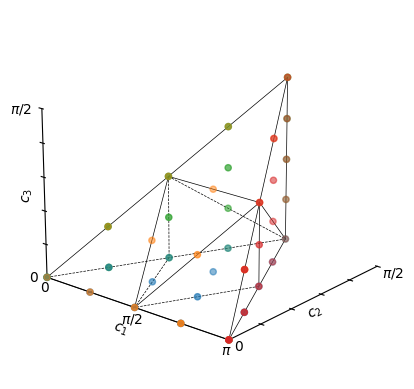

In [92]:
ax = plt.subplot(111, projection="3d")
w = WeylChamber()
w.labels = {}
w.render(ax)
colors = cm.tab10(np.linspace(0, 1.0, 10))


def _tri_linspace(p1, p2, p3, N):
    p1, p2, p3 = (np.array(p) for p in [p1, p2, p3])
    points = []
    for i in range(N):
        for j in range(N - i):
            u = i / (N - 1)
            v = j / (N - 1)
            w = 1 - u - v
            point = tuple(u * p1 + v * p2 + w * p3)
            points.append(point)
    return points


weyl_vertices = [(0, 0, 0), (1, 0, 0), (0.5, 0.5, 0), (0.5, 0.5, 0.5)]
weyl_faces = [
    (weyl_vertices[0], weyl_vertices[1], weyl_vertices[2]),
    (weyl_vertices[0], weyl_vertices[1], weyl_vertices[3]),
    (weyl_vertices[0], weyl_vertices[2], weyl_vertices[3]),
    (weyl_vertices[1], weyl_vertices[2], weyl_vertices[3]),
]
weyl_coords = [_tri_linspace(A, B, C, 5) for A, B, C in weyl_faces]
for idx, inner_cords in enumerate(weyl_coords):
    w.ax.scatter3D(*zip(*inner_cords), color=colors[idx])
weyl_coords = [set([coord for inner in weyl_coords for coord in inner])]

In [93]:
warnings.filterwarnings("ignore", category=InvariantConvergenceWarning)
decomposer = ClosestInvariantSearch(ansatz)
for target_coord in tqdm(weyl_coords[0]):
    decomposer(target_coord)

  0%|          | 0/34 [00:00<?, ?it/s]

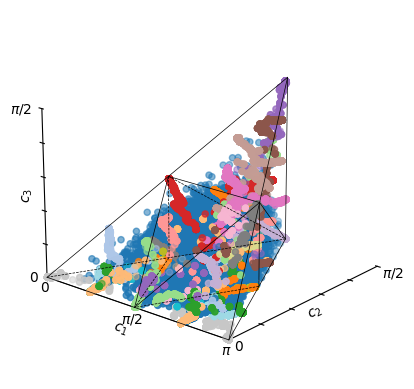

In [94]:
# callback method in ClosestInvariantSearch saves the intermediate points
more_colors = cm.tab20(np.linspace(0, 1.0, 20))
ax = plt.subplot(111, projection="3d", computed_zorder=False)
w = WeylChamber()
w.labels = {}
w.render(ax)
for idx, inner_cords in enumerate(ansatz.weyl_coords):
    w.ax.scatter3D(
        *zip(*inner_cords), color=more_colors[idx % len(more_colors)], zorder=-1
    )

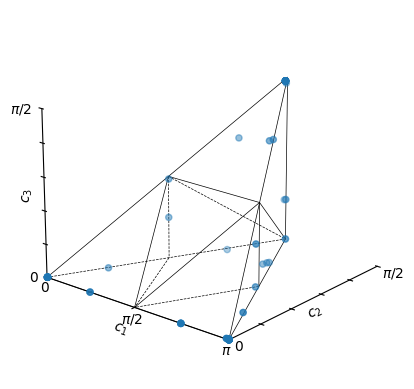

In [95]:
ax = plt.subplot(111, projection="3d")
w = WeylChamber()
w.labels = {}
w.render(ax)

cp = _ansatz_to_circuit_polytope(ansatz)
for idx, subpolytope in enumerate(cp.convex_subpolytopes):
    weyl_vertices = [
        monodromy_to_positive_canonical_coordinate(*monodromy_vertex[:3])
        for monodromy_vertex in subpolytope.vertices
    ]
    weyl_vertices = np.array(weyl_vertices) / (np.pi / 2)
    w.ax.scatter3D(*zip(*weyl_vertices))

In [96]:
haar_volume(cp)

0.30449937093840507